In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import joblib
from tensorflow.keras.models import load_model
from lime import lime_image
from skimage.segmentation import mark_boundaries

I0000 00:00:1781468338.949391    3897 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781468340.003241    3897 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781468343.275316    3897 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
# 1. Load semua model yang sudah disimpan
feature_extractor = load_model('../models/efficientnet_extractor.keras')
scaler = joblib.load('../models/scaler_tuned.pkl')
svm_model = joblib.load('../models/svm_model_tuned.pkl')

W0000 00:00:1781468350.199804    3897 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [4]:
# 2. Buat fungsi Wrapper agar LIME bisa memproses gambar end-to-end
def predict_pipeline(images):
    # Ekstraksi fitur
    features = feature_extractor.predict(images, verbose=0)
    # Normalisasi
    features_scaled = scaler.transform(features)
    # Prediksi probabilitas
    return svm_model.predict_proba(features_scaled)

In [5]:
# 3. Load satu gambar baru untuk didemo
img_path = '../data/raw/sick/20260614_155711.jpg' # Ubah dengan nama file aslimu
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (224, 224))
img_normalized = img_resized / 255.0

In [6]:
# 4. Jalankan LIME
explainer = lime_image.LimeImageExplainer()
# Proses ini akan melakukan 1000 iterasi permutasi gambar
explanation = explainer.explain_instance(img_normalized.astype('double'), predict_pipeline, top_labels=1, hide_color=0, num_samples=1000)

  0%|          | 0/1000 [00:00<?, ?it/s]

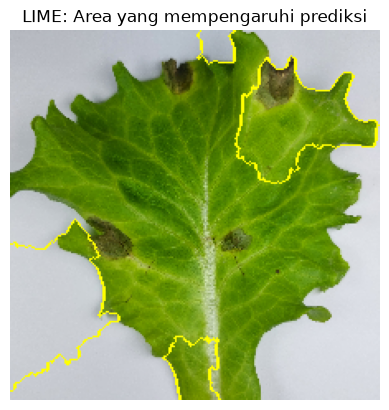

In [7]:
# 5. Visualisasi Area Penting (Bercak Penyakit)
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME: Area yang mempengaruhi prediksi")
plt.axis('off')
plt.show()